In [ ]:
CV 

In [4]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 1.2 MB/s  0:03:00m0:00:0100:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 1.1 MB/s  0:00:10m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 1.0 MB/s  0:00:020m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 1.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 846.8 kB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 1.1 MB/s  0:00:22m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [tensorflow]1 [tensorflow]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# Download data

import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
# ===============================
# STEP 1 — Dataset location
# ===============================

data_dir = "/Users/gregduckworth/Git/CoCT/ds_code_challenge/notebooks/data/swimming_pool"   # folder with yes/ and no/ inside

print("Looking for data in:", data_dir)
print("Exists?", os.path.exists(data_dir))

Looking for data in: /Users/gregduckworth/Git/CoCT/ds_code_challenge/notebooks/data/swimming_pool
Exists? True


In [10]:

# ===============================
# STEP 2 — Load dataset
# ===============================

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    label_mode='binary'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    label_mode='binary'
)

print("Class names:", train_ds.class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)



Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.
Class names: ['no', 'yes']


In [11]:


# ===============================
# STEP 3 — Load ResNet50
# ===============================

base_model = ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

base_model.trainable = False



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 80s 1us/step


In [12]:
# ===============================
# STEP 4 — Build model
# ===============================

model = models.Sequential([

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    base_model,

    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

In [14]:

# ===============================
# STEP 5 — Compile model
# ===============================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [15]:

# ===============================
# STEP 6 — Train model
# ===============================

initial_epochs = 10

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("\nStarting initial training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs,
    callbacks=[lr_scheduler, early_stopping]
)



Starting initial training...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 901ms/step - accuracy: 0.4500 - auc: 0.4548 - loss: 1.0485 - precision: 0.4487 - recall: 0.4375 - val_accuracy: 0.5000 - val_auc: 0.6412 - val_loss: 0.7707 - val_precision: 0.5000 - val_recall: 0.1500 - learning_rate: 1.0000e-04
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 741ms/step - accuracy: 0.5125 - auc: 0.5415 - loss: 0.9618 - precision: 0.5116 - recall: 0.5500 - val_accuracy: 0.6000 - val_auc: 0.7525 - val_loss: 0.6370 - val_precision: 0.7000 - val_recall: 0.3500 - learning_rate: 1.0000e-04
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 739ms/step - accuracy: 0.6125 - auc: 0.6438 - loss: 0.7476 - precision: 0.6184 - recall: 0.5875 - val_accuracy: 0.6750 - val_auc: 0.8250 - val_loss: 0.5516 - val_precision: 0.7692 - val_recall: 0.5000 - learning_rate: 1.0000e-04
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 751ms/step - accuracy: 0.6562 - auc: 0.7243 - loss: 0.6716 - precision: 0.6623 - recall: 0.6375 - val_accuracy: 0.7750 - val_au

In [16]:

# ===============================
# STEP 7 — Fine tuning
# ===============================

print("\nFine-tuning top layers...")

base_model.trainable = True

for layer in base_model.layers[:150]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-6),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

fine_tune_epochs = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs + fine_tune_epochs,
    initial_epoch=history.epoch[-1],
    callbacks=[early_stopping]
)




Fine-tuning top layers...
Epoch 10/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7125 - auc: 0.7883 - loss: 0.6055 - val_accuracy: 0.8500 - val_auc: 0.9025 - val_loss: 0.4258
Epoch 11/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7437 - auc: 0.8163 - loss: 0.5483 - val_accuracy: 0.8500 - val_auc: 0.9000 - val_loss: 0.4295
Epoch 12/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7188 - auc: 0.8195 - loss: 0.5485 - val_accuracy: 0.8250 - val_auc: 0.8913 - val_loss: 0.4337
Epoch 13/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7437 - auc: 0.7956 - loss: 0.5968 - val_accuracy: 0.8250 - val_auc: 0.8875 - val_loss: 0.4369
Epoch 14/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6687 - auc: 0.7817 - loss: 0.6008 - val_accuracy: 0.8250 - val_auc: 0.8825 - val_loss: 0.4411


In [ ]:

# ===============================
# STEP 8 — Save model
# ===============================

model_path = "pool_classifier_resnet50.h5"
model.save(model_path)

print("\nModel saved to:", model_path)


In [17]:

# ===============================
# STEP 9 — Evaluate model
# ===============================

print("\nFinal Evaluation:")

loss, accuracy, auc = model.evaluate(val_ds)

print(f"Accuracy: {accuracy:.2%}")
print(f"AUC: {auc:.4f}")
print(f"Loss: {loss:.4f}")



Final Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.8500 - auc: 0.9025 - loss: 0.4258
Accuracy: 85.00%
AUC: 0.9025
Loss: 0.4258


In [21]:

val_images, val_labels = next(iter(val_ds))
preds = model.predict(val_images)

for i in range(40):

    true_class = "pool" if val_labels[i] == 1 else "no_pool"

    prob = preds[i][0]
    pred_class = "pool" if prob > 0.5 else "no_pool"

    confidence = prob if pred_class == "pool" else 1-prob

    print(
        f"True: {true_class:<8} | "
        f"Pred: {pred_class:<8} | "
        f"Confidence: {confidence:.2%}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
True: no_pool  | Pred: no_pool  | Confidence: 99.57%
True: no_pool  | Pred: no_pool  | Confidence: 64.34%
True: no_pool  | Pred: no_pool  | Confidence: 55.62%
True: no_pool  | Pred: pool     | Confidence: 76.53%
True: no_pool  | Pred: no_pool  | Confidence: 70.34%
True: pool     | Pred: pool     | Confidence: 81.55%
True: no_pool  | Pred: no_pool  | Confidence: 99.56%
True: no_pool  | Pred: no_pool  | Confidence: 98.13%
True: pool     | Pred: pool     | Confidence: 96.73%
True: pool     | Pred: pool     | Confidence: 94.27%
True: pool     | Pred: pool     | Confidence: 94.36%
True: pool     | Pred: pool     | Confidence: 73.92%
True: no_pool  | Pred: pool     | Confidence: 94.96%
True: no_pool  | Pred: no_pool  | Confidence: 87.69%
True: pool     | Pred: pool     | Confidence: 91.80%
True: no_pool  | Pred: pool     | Confidence: 59.15%
True: pool     | Pred: pool     | Confidence: 62.20%
True: pool     | Pred: pool     | Confidence: 85.49%
True: p

W0000 00:00:1773414329.742087  380357 op_kernel.cc:1858] OP_REQUIRES failed at strided_slice_op.cc:117 : INVALID_ARGUMENT: slice index 32 of dimension 0 out of bounds.
W0000 00:00:1773414329.742114  380357 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: slice index 32 of dimension 0 out of bounds.


InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:CPU:0}} slice index 32 of dimension 0 out of bounds. [Op:StridedSlice] name: strided_slice/

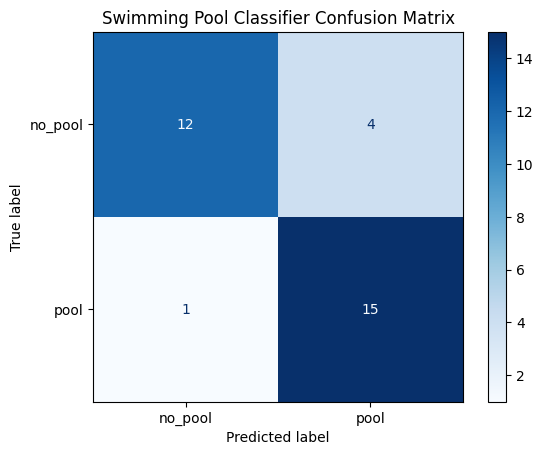

In [22]:
## CM

import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# True labels (0=no, 1=yes)
true_labels = val_labels.numpy().astype(int)

# Predicted labels
pred_labels = (preds > 0.5).astype(int).flatten()

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no_pool', 'pool'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Swimming Pool Classifier Confusion Matrix")
plt.show()


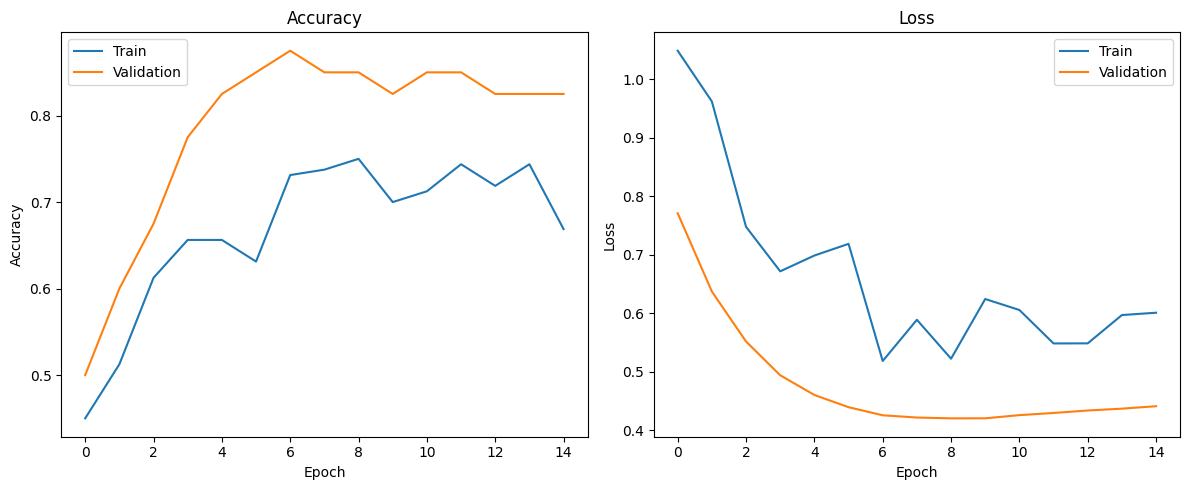

In [19]:

# ===============================
# STEP 11 — Training plots
# ===============================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'] + history_fine.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])


plt.subplot(1,2,2)

plt.plot(history.history['loss'] + history_fine.history['loss'])
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()
plt.show()